In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'AdidasSalesdata.xlsx'
df = pd.read_excel(file_path)

# Preview the data
print("Data preview:")
print(df.head())

Data preview:
      Retailer  Retailer ID Invoice Date     Region         State  \
0  Foot Locker      1185732   2021-10-26  Northeast  Pennsylvania   
1  Foot Locker      1185732   2021-10-27  Northeast  Pennsylvania   
2  Foot Locker      1185732   2021-10-28  Northeast  Pennsylvania   
3  Foot Locker      1185732   2021-10-29  Northeast  Pennsylvania   
4  Foot Locker      1185732   2021-10-30  Northeast  Pennsylvania   

           City Gender Type   Product Category  Price per Unit  Units Sold  \
0  Philadelphia         Men            Apparel              55         125   
1  Philadelphia       Women            Apparel              45         225   
2  Philadelphia         Men    Street Footwear              45         475   
3  Philadelphia         Men  Athletic Footwear              45         125   
4  Philadelphia       Women    Street Footwear              35         175   

   Total Sales  Operating Profit  Operating Margin Sales Method  
0      68750.0           24062.5    

In [3]:
# 1. Group by Product Category and calculate average operating margin
category_margin = df.groupby('Product Category')['Operating Margin'].mean().sort_values(ascending=False)
print("\nAverage Operating Margin by Product Category:")
print(category_margin)


Average Operating Margin by Product Category:
Product Category
Street Footwear      0.428176
Apparel              0.427281
Athletic Footwear    0.413517
Name: Operating Margin, dtype: float64


In [4]:
# 2. Group by Product Category and total sales
category_sales = df.groupby('Product Category')['Total Sales'].sum().sort_values(ascending=False)
print("\nTotal Sales by Product Category:")
print(category_sales)


Total Sales by Product Category:
Product Category
Street Footwear      336829057.0
Apparel              302767492.0
Athletic Footwear    260305576.0
Name: Total Sales, dtype: float64


In [5]:
# 3. Group by Retailer and Product Category for margin analysis
retailer_category_margin = df.groupby(['Retailer', 'Product Category'])['Operating Margin'].mean().unstack()
print("\nAverage Operating Margin by Retailer and Product Category:")
print(retailer_category_margin)


Average Operating Margin by Retailer and Product Category:
Product Category   Apparel  Athletic Footwear  Street Footwear
Retailer                                                      
Amazon            0.409241           0.414069         0.430316
Foot Locker       0.421305           0.409355         0.423191
Kohl's            0.402974           0.405219         0.449593
Sports Direct     0.454279           0.446770         0.433589
Walmart           0.409636           0.397524         0.412400
West Gear         0.433283           0.397332         0.422972


In [6]:
# 4. Group by Sales Method and Product Category for margin analysis
channel_margin = df.groupby(['Sales Method', 'Product Category'])['Operating Margin'].mean().unstack()
print("\nAverage Operating Margin by Sales Method and Product Category:")
print(channel_margin)


Average Operating Margin by Sales Method and Product Category:
Product Category   Apparel  Athletic Footwear  Street Footwear
Sales Method                                                  
In-store          0.366351           0.343869         0.358103
Online            0.469859           0.454313         0.468289
Outlet            0.393532           0.387527         0.403565


In [7]:
# 5. Group by City and Product Category for margin analysis
city_category_margin = df.groupby(['City', 'Product Category'])['Operating Margin'].mean().unstack()
print("\nAverage Operating Margin by City and Product Category (sample):")
print(city_category_margin.head())


Average Operating Margin by City and Product Category (sample):
Product Category   Apparel  Athletic Footwear  Street Footwear
City                                                          
Albany            0.475833           0.380208         0.422708
Albuquerque       0.333472           0.431944         0.413333
Anchorage         0.338261           0.354792         0.355800
Atlanta           0.366528           0.446250         0.428333
Baltimore         0.368333           0.414792         0.439167


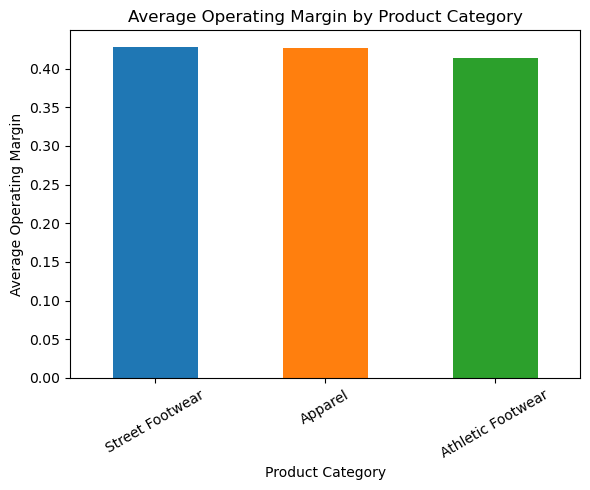

In [9]:
# Visualization: Average Operating Margin by Product Category
plt.figure(figsize=(6,5))
category_margin.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Average Operating Margin')
plt.title('Average Operating Margin by Product Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('avg_margin_by_category.png')
plt.show()

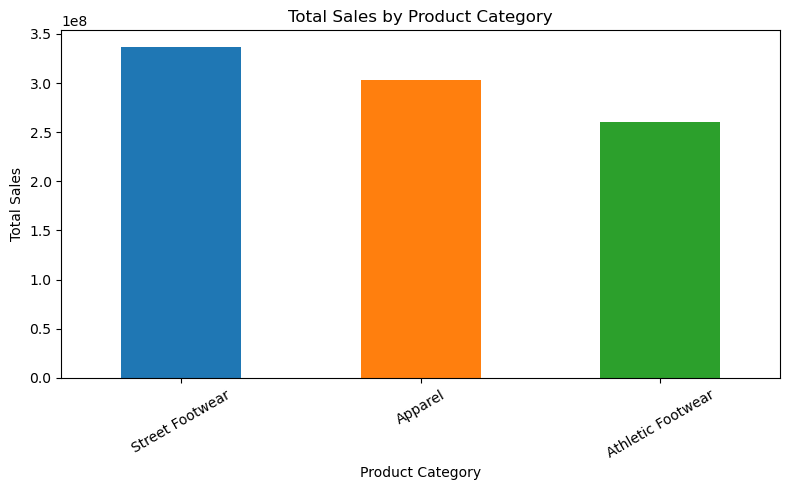

In [10]:
#(Optional) Visualization: Total Sales by Product Category
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Total Sales')
plt.title('Total Sales by Product Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('total_sales_by_category.png')
plt.show()

In [11]:
# Key Insights
key_insights = [
    "Street Footwear drives highest profits across regions with margins often 0.4-0.55 and large sales volumes.",
    "Retailer and channel performance is uneven; outlet and online channels for footwear have higher margins than apparel.",
    "Apparel underperforms in margin and volume, especially women's apparel, indicating need for product refresh or marketing repositioning."
]

# Business Recommendation
business_recommendation = (
    "Focus marketing and inventory investment on Street Footwear, especially in urban centers and through outlet and online channels, "
    "as these yield highest profits and sales growth. Reallocate budget from underperforming Apparel lines to support new product launches or targeted campaigns in footwear. "
    "Pilot city-specific promotions in Philadelphia and Houston where Street Footwear dominates, and consider product refresh or promotional push for Apparel to boost profitability."
)

print("\n--- KEY INSIGHTS ---")
for idx, insight in enumerate(key_insights, 1):
    print(f"{idx}. {insight}")

print("\n--- BUSINESS RECOMMENDATION ---")
print(business_recommendation)


--- KEY INSIGHTS ---
1. Street Footwear drives highest profits across regions with margins often 0.4-0.55 and large sales volumes.
2. Retailer and channel performance is uneven; outlet and online channels for footwear have higher margins than apparel.
3. Apparel underperforms in margin and volume, especially women's apparel, indicating need for product refresh or marketing repositioning.

--- BUSINESS RECOMMENDATION ---
Focus marketing and inventory investment on Street Footwear, especially in urban centers and through outlet and online channels, as these yield highest profits and sales growth. Reallocate budget from underperforming Apparel lines to support new product launches or targeted campaigns in footwear. Pilot city-specific promotions in Philadelphia and Houston where Street Footwear dominates, and consider product refresh or promotional push for Apparel to boost profitability.
